# Regime-dependent efficiency — is the directional signal episodic? (AMH test)

The conditional-mean chapter found a weak **directional** signal: in the linear models, COT
positioning and the paid-news title score call the *sign* of the weekly return better than chance
(Pesaran–Timmermann significant pooled), yet the signal is magnitude-worthless, concentrated in
2025, and does not replicate in the nonlinear families. The Discussion reads this through the
**adaptive-markets hypothesis** (Lo 2004): efficiency as a time-varying equilibrium, predictability
that comes and goes rather than an absolute. That reading was *interpretive*. This notebook
**tests it** two ways:

1. **Rolling out-of-sample directional skill** — does the signal flare up and die down over time,
   even though it washes out when pooled?
2. **A two-regime Markov-switching regression** — does the predictor's coefficient *switch*
   between a near-zero ("efficient") regime and a non-zero ("predictable") one, and does the
   predictable regime line up with turbulent episodes?

Both are descriptive/structural — the goal is to characterise *when* the weak signal lives, not to
claim an exploitable forecast.

### Why these two predictors

The test conditions on *exactly* the signal it interrogates — the only features that showed
**directional** skill in the conditional-mean chapter. The selection criterion is a single one:
they are the two predictors whose sign forecasts cleared the **Pesaran–Timmermann** test (beating
chance, base-rate aware) in the linear models.

- **`cot_mm_net_pct`** — COT managed-money net positioning. PT-significant in the **ARIMAX** ladder
  (`+COT` p=0.038, rising to p=0.002 once more groups are added); COT-free single-group rungs do
  not clear PT.
- **`news_paid_sentiment_title`** — FinBERT on the paid-news headline. PT-significant in **VAR**
  (`+NewsPaid` p=0.002) and **MIDAS** (`+SentimentPaid` p=0.003) — the only sentiment encoding to
  replicate the directional signal across two linear families.

No other feature in the set clears PT, so these are the *only* directional content worth asking the
"is it episodic?" (AMH) question about. Both stay **magnitude-worthless** (every rung DM-ties the
drift floor), so what follows characterises *when* a weak sign signal lives — not a tradable
forecast. Note the two earned their PT credentials in *different* model families and are pooled here
into one regression: a deliberately parsimonious directional spec, not a single pre-validated rung.

In [1]:
import sys; sys.path.insert(0, '../../src')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from eval_utils import pesaran_timmermann

fw = pd.read_csv('../../data/processed/features_weekly.csv', parse_dates=['week_end']).set_index('week_end')

# the two PT-significant directional predictors, lagged one week, standardised
PRED = ['cot_mm_net_pct', 'news_paid_sentiment_title']
d  = pd.concat([fw['silver_return'].rename('y'), fw[PRED].shift(1)], axis=1).dropna()
Xz = (d[PRED] - d[PRED].mean()) / d[PRED].std()
print(f'n = {len(d)} weeks,  {d.index.min().date()} .. {d.index.max().date()}')

n = 588 weeks,  2015-01-16 .. 2026-05-01


## Part A — rolling out-of-sample directional skill

At each week (after a two-year warm-up) we fit an expanding-window OLS of the return on the two
lagged predictors, forecast the next week, and keep the sign. We then track the directional
accuracy and the Pesaran–Timmermann $p$-value over a rolling 52-week window. If efficiency were
constant the $p$-value would hover near uniform; if it is adaptive the signal should *cluster* in
particular regimes.

In [2]:
MINW = 104                                            # 2-year warm-up
y = d['y'].values
Xmat = sm.add_constant(Xz.values)
fc = pd.Series(index=d.index, dtype=float)
for t in range(MINW, len(d)):
    b = np.linalg.lstsq(Xmat[:t], y[:t], rcond=None)[0]
    fc.iloc[t] = Xmat[t] @ b
oos = pd.DataFrame({'y': d['y'], 'fc': fc}).dropna()

print(f'Pooled OOS directional test ({len(oos)} weeks):')
pt_full = pesaran_timmermann(oos['y'].values, oos['fc'].values, name='COT+PaidTitle (expanding OOS)')

W = 52
roll = []
for i in range(W, len(oos) + 1):
    s = oos.iloc[i - W:i]
    da = float(np.mean(np.sign(s['y']) == np.sign(s['fc'])))
    roll.append((s.index[-1], da, pesaran_timmermann(s['y'].values, s['fc'].values)['p']))
roll = pd.DataFrame(roll, columns=['date', 'da', 'pt_p']).set_index('date')
print(f"\nrolling 52w windows with PT p<0.10: {(roll['pt_p'] < 0.10).mean():.1%}")

# Each row describes weekly 52-week windows ENDING in that calendar year.
# These are not separate annual PT tests: adjacent windows share 51 of 52 weeks.
yearly_pt = roll.groupby(roll.index.year).agg(
    windows=('pt_p', 'size'),
    min_p=('pt_p', 'min'),
    windows_p05=('pt_p', lambda p: int((p < 0.05).sum())),
)
print('\nRolling PT summary by window-ending year:')
print(yearly_pt.round({'min_p': 3}).to_string())

Pooled OOS directional test (484 weeks):
COT+PaidTitle (expanding OOS)             DA=0.543  DA|indep=0.511  PT=+1.458  p=0.145  (ns)  -> winner: tie (chance)

rolling 52w windows with PT p<0.10: 16.4%

Rolling PT summary by window-ending year:
      windows  min_p  windows_p05
date                             
2018       50  0.161            0
2019       52  0.166            0
2020       52  0.179            0
2021       53  0.009            7
2022       52  0.021            3
2023       52  0.145            0
2024       52  0.024           12
2025       52  0.033            4
2026       18  0.269            0


**Reading.** Pooled over the whole window the signal is **insignificant** (PT $p=0.145$).
Of 433 rolling windows, 26 (6.0%) clear $p<0.05$, with their endpoints concentrated in
2021–22 and 2024–25. This recurrence is suggestive of temporal instability, but the windows
are not independent: consecutive tests reuse 51 of 52 observations. Inspecting 433 $p$-values
also makes some chance crossings of 0.05 likely. The pattern is therefore descriptive, not a
standalone rejection of constant efficiency.

## Part B — a two-regime Markov-switching regression

We let the data, not the calendar, pick the regimes:
$$r_t = \alpha_{S_t} + \beta_{S_t}'\,x_{t-1} + \varepsilon_t,\qquad \varepsilon_t\sim N(0,\sigma^2_{S_t}),$$
with a latent two-state Markov chain $S_t$. Here $x_{t-1}$ contains the two standardised,
one-week-lagged predictors in this fixed order:

- `x1` = `cot_mm_net_pct` (COT managed-money net positioning)
- `x2` = `news_paid_sentiment_title` (paid-news title sentiment)

`statsmodels` uses the generic names `x1` and `x2` because the model receives the NumPy array
`Xz.values`, which does not retain DataFrame column names. If the predictive coefficient $\beta$
is regime-switching — near zero in one state, non-zero in another — predictability is structurally
intermittent.

In [3]:
from scipy.stats import chi2

# Xz follows the order in PRED. Passing .values removes the column names, so the
# statsmodels summary calls cot_mm_net_pct "x1" and news_paid_sentiment_title "x2".
mod = MarkovRegression(d['y'].values * 100, k_regimes=2, exog=Xz.values, switching_variance=True)
res = mod.fit(maxiter=300)
pdict = dict(zip(res.model.param_names, res.params))
sig2 = [pdict[f'sigma2[{k}]'] for k in range(2)]
hi = int(np.argmax(sig2))                              # turbulent regime = higher variance
print(f'turbulent regime = {hi}  (sigma2 = {np.round(sig2, 2)});  '
      f'expected durations (wk) = {np.round(res.expected_durations, 1)}')
for k in range(2):
    tag = 'turbulent' if k == hi else 'calm'
    print(f'  regime {k} [{tag:9s}]: beta_COT={pdict[f"x1[{k}]"]:+.3f}  '
          f'beta_Paid={pdict[f"x2[{k}]"]:+.3f}  sigma2={sig2[k]:.2f}')
print('\nCoefficient names used in the statsmodels summary:')
print(f'  x1 = {Xz.columns[0]}  (COT managed-money net positioning)')
print(f'  x2 = {Xz.columns[1]}  (paid-news title sentiment)')

# Direct Wald tests compare parameters ACROSS regimes. These differ from the
# summary p-values, which test whether one regime-specific parameter equals zero.
param_names = res.model.param_names
param_cov = np.asarray(res.cov_params())

def wald_equal_across_regimes(param):
    """Test H0: param[0] = param[1] using the full parameter covariance matrix."""
    i0, i1 = param_names.index(f'{param}[0]'), param_names.index(f'{param}[1]')
    difference = res.params[i1] - res.params[i0]
    difference_var = param_cov[i1, i1] + param_cov[i0, i0] - 2 * param_cov[i1, i0]
    se = np.sqrt(difference_var)
    statistic = (difference / se) ** 2
    return {'difference': difference, 'se': se, 'wald': statistic,
            'p': chi2.sf(statistic, df=1)}

wald_variance = wald_equal_across_regimes('sigma2')
wald_paid = wald_equal_across_regimes('x2')
print(f"\nEqual regime variances: Wald p={wald_variance['p']:.4f}")
print(f"Equal paid-news coefficients: Wald p={wald_paid['p']:.4f}")
print(res.summary().tables[1]); print(res.summary().tables[2])

turbulent regime = 1  (sigma2 = [10.47 64.86]);  expected durations (wk) = [71.1 11.7]
  regime 0 [calm     ]: beta_COT=-0.236  beta_Paid=-0.218  sigma2=10.47
  regime 1 [turbulent]: beta_COT=+0.370  beta_Paid=-2.230  sigma2=64.86

Coefficient names used in the statsmodels summary:
  x1 = cot_mm_net_pct  (COT managed-money net positioning)
  x2 = news_paid_sentiment_title  (paid-news title sentiment)

Equal regime variances: Wald p=0.0027
Equal paid-news coefficients: Wald p=0.1156
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1499      0.156      0.958      0.338      -0.157       0.456
x1            -0.2361      0.145     -1.626      0.104      -0.521       0.048
x2            -0.2179      0.147     -1.482      0.138      -0.506       0.070
sigma2        10.4709      0.965     10

**Reading.** The chain splits into a long **calm** regime (~71-week duration) and short
**turbulent** bursts (~12 weeks), with about six times the variance. A direct Wald test rejects
equal regime variances ($p=0.0027$), supporting the volatility-state distinction. The paid-news
coefficient is more negative in the turbulent state in point-estimate terms ($-2.23$ versus
$-0.22$), but the coefficients do not differ significantly across states (Wald $p=0.116$).
The model therefore identifies volatility regimes, not confirmed regimes of directional
predictability.


PT p<0.05 endpoints in turbulent state: 0/26
PT p<0.05 windows containing any turbulent week: 7/26


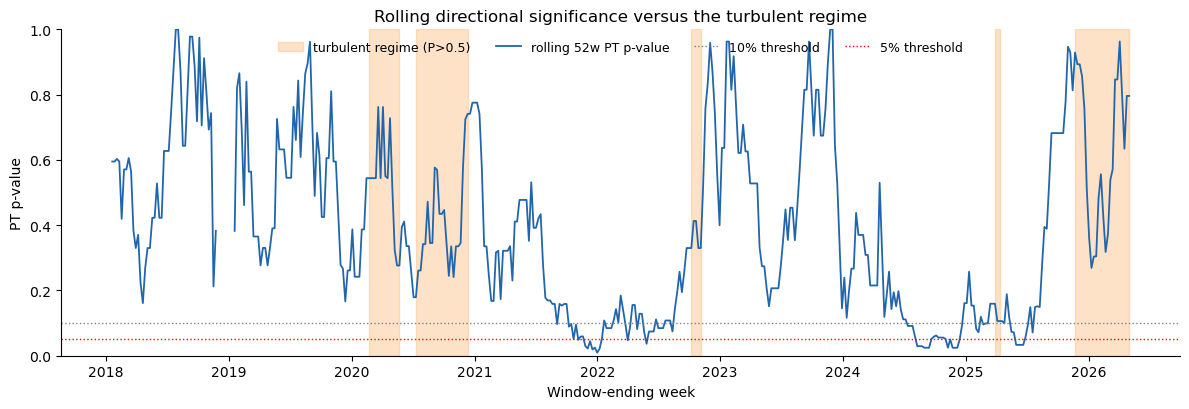

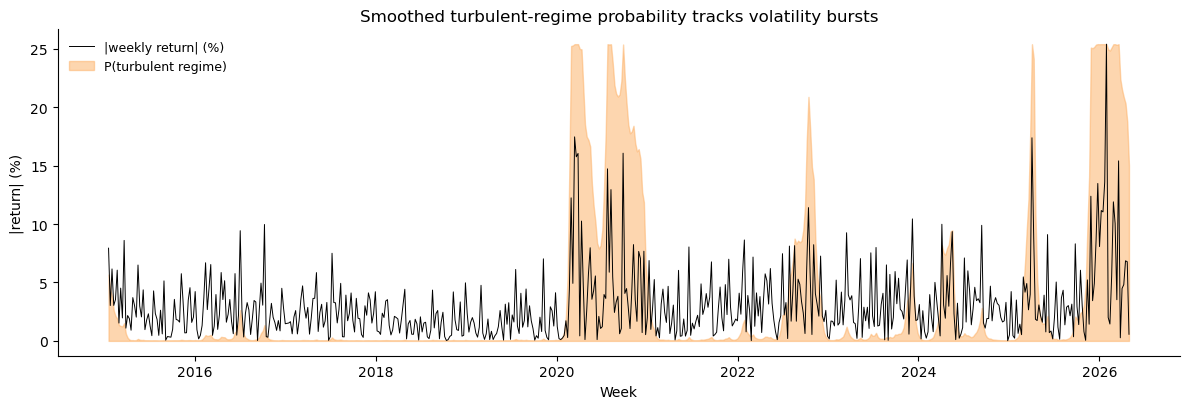

In [4]:
# Main-report figure: rolling directional significance and turbulent states
phi = pd.Series(res.smoothed_marginal_probabilities[:, hi], index=d.index)   # P(turbulent)

# Align each significant PT endpoint with both its endpoint state and all 52 weeks
# used by that test. This checks whether the Part A and Part B episodes actually overlap.
significant_endpoints = roll.index[roll['pt_p'] < 0.05]
endpoint_turbulent = int((phi.reindex(significant_endpoints) > 0.5).sum())
windows_containing_turbulence = 0
for endpoint in significant_endpoints:
    endpoint_position = oos.index.get_loc(endpoint)
    window_weeks = oos.index[endpoint_position - W + 1:endpoint_position + 1]
    windows_containing_turbulence += int((phi.reindex(window_weeks) > 0.5).any())
print(f'\nPT p<0.05 endpoints in turbulent state: {endpoint_turbulent}/{len(significant_endpoints)}')
print(f'PT p<0.05 windows containing any turbulent week: '
      f'{windows_containing_turbulence}/{len(significant_endpoints)}')

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.fill_between(phi.index, 0, 1, where=phi > 0.5, color='#fdae61', alpha=0.35,
                transform=ax.get_xaxis_transform(), label='turbulent regime (P>0.5)')
ax.plot(roll.index, roll['pt_p'], color='#2166ac', lw=1.3, label='rolling 52w PT p-value')
ax.axhline(0.10, color='grey', ls=':', lw=1, label='10% threshold')
ax.axhline(0.05, color='red', ls=':', lw=1, label='5% threshold')
ax.set_ylim(0, 1); ax.set_ylabel('PT p-value'); ax.set_xlabel('Window-ending week')
ax.legend(frameon=False, ncol=4, fontsize=9)
ax.set_title('Rolling directional significance versus the turbulent regime')
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig('../../images/regime_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Appendix validation figure: the inferred turbulent state should track volatility bursts.
fig_val, ax_val = plt.subplots(figsize=(12, 4.2))
ax_val.plot(d.index, (d['y'] * 100).abs(), color='black', lw=0.7,
            label='|weekly return| (%)')
ax_val.fill_between(phi.index, 0, phi * (d['y'] * 100).abs().max(),
                    color='#fdae61', alpha=0.5, label='P(turbulent regime)')
ax_val.set_ylabel('|return| (%)'); ax_val.set_xlabel('Week')
ax_val.legend(frameon=False, fontsize=9)
ax_val.set_title('Smoothed turbulent-regime probability tracks volatility bursts')
for sp in ('top', 'right'): ax_val.spines[sp].set_visible(False)
plt.tight_layout()
fig_val.savefig('../../images/regime_volatility_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Persist a compact summary
summary = pd.DataFrame({
    'metric': ['pooled_PT', 'pooled_PT_p', 'rolling_frac_p<0.10', 'rolling_frac_p<0.05',
               'rolling_p05_endpoint_turbulent', 'rolling_p05_window_any_turbulent',
               'sigma2_calm', 'sigma2_turbulent', 'wald_equal_variance_p',
               'dur_calm_wk', 'dur_turbulent_wk', 'beta_paid_calm',
               'beta_paid_turbulent', 'wald_equal_paid_p'],
    'value': [round(pt_full['PT'], 3), round(pt_full['p'], 3),
              round((roll['pt_p'] < 0.10).mean(), 3),
              round((roll['pt_p'] < 0.05).mean(), 3),
              endpoint_turbulent, windows_containing_turbulence,
              round(sig2[1 - hi], 2), round(sig2[hi], 2),
              round(wald_variance['p'], 4),
              round(res.expected_durations[1 - hi], 1), round(res.expected_durations[hi], 1),
              round(pdict[f'x2[{1 - hi}]'], 3), round(pdict[f'x2[{hi}]'], 3),
              round(wald_paid['p'], 4)]})
summary.to_csv('../../data/processed/metrics_regime_efficiency.csv', index=False)
print(summary.to_string(index=False))

                          metric   value
                       pooled_PT  1.4580
                     pooled_PT_p  0.1450
             rolling_frac_p<0.10  0.1640
             rolling_frac_p<0.05  0.0600
  rolling_p05_endpoint_turbulent  0.0000
rolling_p05_window_any_turbulent  7.0000
                     sigma2_calm 10.4700
                sigma2_turbulent 64.8600
           wald_equal_variance_p  0.0027
                     dur_calm_wk 71.1000
                dur_turbulent_wk 11.7000
                  beta_paid_calm -0.2180
             beta_paid_turbulent -2.2300
               wald_equal_paid_p  0.1156


## Takeaway

The pooled directional signal is insignificant, while low rolling PT $p$-values recur in
2021–22 and 2024–25. Because the 52-week windows overlap heavily and hundreds of $p$-values are
inspected, this is descriptive evidence of temporal instability rather than a formal rejection
of constant efficiency. The Markov model independently identifies statistically distinct calm
and turbulent volatility states, but those states do not explain the rolling PT episodes: none
of the 26 significant endpoints is turbulent and only seven significant windows contain any
turbulent week. The result is therefore **episodic but not demonstrably volatility-regime-bound**,
and it does not overturn the magnitude-efficiency verdict.

Outputs: `metrics_regime_efficiency.csv`, `images/regime_efficiency.png`, and
`images/regime_volatility_validation.png`.